# Notebook 06: Neural SDE with External Inputs

Forward-pass-only demo connecting the full neural pipeline:

1. **Encoder invariance** — same CRN, different protocols → identical `CRNContext`
2. **Protocol encoding** — `ProtocolEncoder` maps pulse schedules to embeddings
3. **Neural SDE conditioning** — drift/diffusion change with protocol embedding
4. **Full forward pass** — `EulerMaruyamaSolver` with clamped external species

The model is untrained (random weights), so trajectory values are nonsensical.  
The goal is to verify that the pipeline assembles and executes correctly.

In [7]:
import torch
import matplotlib.pyplot as plt

from crn_surrogate.crn.crn import CRN
from crn_surrogate.crn.reaction import Reaction
from crn_surrogate.crn.propensities import hill, mass_action
from crn_surrogate.crn.inputs import (
    EMPTY_PROTOCOL,
    InputProtocol,
    single_pulse,
    repeated_pulse,
)
from crn_surrogate.encoder.tensor_repr import crn_to_tensor_repr
from crn_surrogate.encoder.bipartite_gnn import BipartiteGNNEncoder
from crn_surrogate.encoder.protocol_encoder import ProtocolEncoder
from crn_surrogate.configs.model_config import EncoderConfig, SDEConfig, ProtocolEncoderConfig
from crn_surrogate.simulator.neural_sde import CRNNeuralSDE
from crn_surrogate.simulator.sde_solver import EulerMaruyamaSolver

torch.manual_seed(42)

## CRN: birth-death with external inducer

Two species:
- **A** (index 0): internal protein undergoing birth and degradation  
- **I** (index 1): external inducer controlled by an `InputProtocol`

Reactions:
- ∅ → A  (Hill activation by I, v_max=5, k_m=10, n=2)
- A → ∅  (degradation, rate 0.2 · A)

In [8]:
# Build CRN with one external species (inducer = species index 1)
crn = CRN(
    reactions=[
        Reaction(
            stoichiometry=torch.tensor([1, 0]),
            propensity=hill(v_max=5.0, k_m=10.0, hill_coefficient=2.0, species_index=1),
            name="A production",
        ),
        Reaction(
            stoichiometry=torch.tensor([-1, 0]),
            propensity=mass_action(0.2, torch.tensor([1.0, 0.0])),
            name="A degradation",
        ),
    ],
    species_names=["A", "I"],
    external_species=frozenset({1}),
)

print(f"n_species={crn.n_species}, n_reactions={crn.n_reactions}")
print(f"external_species: {crn.external_species}")
print(f"is_external mask: {crn.is_external}")

n_species=2, n_reactions=2
external_species: frozenset({1})
is_external mask: [False  True]


In [9]:
# Convert to tensor representation used by the encoder
crn_repr = crn_to_tensor_repr(crn)
print(f"stoichiometry shape: {crn_repr.stoichiometry.shape}")
print(f"is_external: {crn_repr.is_external}")

stoichiometry shape: torch.Size([2, 2])
is_external: tensor([False,  True])


## Section 1: Encoder invariance

The `BipartiteGNNEncoder` encodes CRN structure, not the experimental protocol.  
Encoding the same CRN with three different initial states should produce three
different context vectors (state is part of the input), but the **same CRN**
at the **same initial state** must always produce the **same context vector**
regardless of what protocol will be applied downstream.

In [10]:
encoder_cfg = EncoderConfig(d_model=32, n_layers=2)
encoder = BipartiteGNNEncoder(encoder_cfg)
encoder.eval()

initial_state = torch.tensor([5.0, 0.0])  # A=5, I=0 (inducer starts at zero)

with torch.no_grad():
    ctx_run1 = encoder(crn_repr, initial_state)
    ctx_run2 = encoder(crn_repr, initial_state)

# Two forward passes on the same input must be identical (no stochasticity in encoder).
max_diff = (ctx_run1.context_vector - ctx_run2.context_vector).abs().max().item()
print(f"Max difference between two encoder runs: {max_diff:.2e}  (should be 0)")

print(f"context_vector shape: {ctx_run1.context_vector.shape}")
print(f"context_vector[:6]: {ctx_run1.context_vector[:6].tolist()}")

Max difference between two encoder runs: 0.00e+00  (should be 0)
context_vector shape: torch.Size([64])
context_vector[:6]: [-0.43142062425613403, -0.17256435751914978, 0.21919593214988708, 1.0121625661849976, 0.18193477392196655, 0.2014448344707489]


In [11]:
# Different initial states produce different context vectors.
initial_state_alt = torch.tensor([20.0, 0.0])

with torch.no_grad():
    ctx_alt = encoder(crn_repr, initial_state_alt)

max_diff_vs_alt = (ctx_run1.context_vector - ctx_alt.context_vector).abs().max().item()
print(f"Max difference (A=5 vs A=20): {max_diff_vs_alt:.4f}  (expected nonzero)")

Max difference (A=5 vs A=20): 0.3206  (expected nonzero)


## Section 2: Protocol encoding

Three protocols are encoded with `ProtocolEncoder`:
- **Empty** (`EMPTY_PROTOCOL`): no events → zero embedding
- **Single pulse**: one rectangular pulse at t=10..20, amplitude=15
- **Repeated pulse**: four pulses, amplitude=20

In [12]:
# single_pulse / repeated_pulse return PulseSchedule; wrap in InputProtocol for the encoder.
protocol_empty = EMPTY_PROTOCOL

schedule_single = single_pulse(t_start=10.0, t_end=20.0, amplitude=15.0)
protocol_single = InputProtocol(schedules={1: schedule_single})

schedule_repeated = repeated_pulse(
    period=10.0,
    duty_cycle=0.5,
    amplitude=20.0,
    n_pulses=4,
    t_start=0.0,
)
protocol_repeated = InputProtocol(schedules={1: schedule_repeated})

print("Empty   :", protocol_empty)
print("Single  :", protocol_single)
n_rep_events = len(list(protocol_repeated.schedules.values())[0].events)
print(f"Repeated: {n_rep_events} events")

Empty   : InputProtocol(schedules={})
Single  : InputProtocol(schedules={1: PulseSchedule(events=(PulseEvent(t_start=10.0, t_end=20.0, amplitude=15.0),), baseline=0.0)})
Repeated: 4 events


In [13]:
d_protocol = 64
protocol_cfg = ProtocolEncoderConfig(
    d_event=32,
    d_protocol=d_protocol,
    n_layers=2,
    max_input_species=8,
    species_embed_dim=8,
)
protocol_encoder = ProtocolEncoder(protocol_cfg)
protocol_encoder.eval()

with torch.no_grad():
    emb_empty    = protocol_encoder([protocol_empty])
    emb_single   = protocol_encoder([protocol_single])
    emb_repeated = protocol_encoder([protocol_repeated])

print(f"Embedding shape:   {emb_empty.shape}  (batch=1, d_protocol={d_protocol})")
print(f"Empty  max abs:    {emb_empty.abs().max().item():.6f}  (must be 0)")
print(f"Single max abs:    {emb_single.abs().max().item():.4f}")
print(f"Repeated max abs:  {emb_repeated.abs().max().item():.4f}")

Embedding shape:   torch.Size([1, 64])  (batch=1, d_protocol=64)
Empty  max abs:    0.000000  (must be 0)
Single max abs:    1.9287
Repeated max abs:  7.4990


In [14]:
# Verify that different protocols produce different embeddings
diff_sr = (emb_single - emb_repeated).abs().max().item()
print(f"Single vs repeated embedding max diff: {diff_sr:.4f}  (expected nonzero)")

Single vs repeated embedding max diff: 5.5703  (expected nonzero)


In [15]:
# Encode a batch of all three protocols at once
with torch.no_grad():
    emb_batch = protocol_encoder([protocol_empty, protocol_single, protocol_repeated])

print(f"Batch embedding shape: {emb_batch.shape}  (batch=3, d_protocol={d_protocol})")
print(f"Row 0 (empty) max abs: {emb_batch[0].abs().max().item():.6f}")
print(f"Row 1 (single) matches single: "
      f"{(emb_batch[1] - emb_single[0]).abs().max().item():.2e}")
print(f"Row 2 (repeated) matches repeated: "
      f"{(emb_batch[2] - emb_repeated[0]).abs().max().item():.2e}")

Batch embedding shape: torch.Size([3, 64])  (batch=3, d_protocol=64)
Row 0 (empty) max abs: 0.000000
Row 1 (single) matches single: 4.77e-07
Row 2 (repeated) matches repeated: 7.15e-07


## Section 3: Neural SDE conditioning

Construct a `CRNNeuralSDE` with `d_protocol > 0` and evaluate drift and diffusion
at a test state. The same CRN context with different protocol embeddings must
produce different outputs — the protocol conditioning is active.

In [16]:
sde_cfg = SDEConfig(
    d_model=encoder_cfg.d_model,
    d_hidden=64,
    n_noise_channels=crn.n_reactions,
    n_hidden_layers=2,
    clip_state=True,
    d_protocol=d_protocol,
)

sde = CRNNeuralSDE(sde_cfg, n_species=crn.n_species)
sde.eval()

print(f"SDE d_context = 2*{encoder_cfg.d_model} + {d_protocol} = "
      f"{2 * encoder_cfg.d_model + d_protocol}")

SDE d_context = 2*32 + 64 = 128


In [17]:
# Evaluate drift at the initial state with two different protocol embeddings
crn_ctx = ctx_run1  # CRNContext from Section 1
state_1d = initial_state
t_test = torch.tensor(0.0)

emb_A = emb_single[0]    # (d_protocol,)
emb_B = emb_repeated[0]  # (d_protocol,)

with torch.no_grad():
    drift_A = sde.drift(t_test, state_1d, crn_ctx, protocol_embedding=emb_A)
    drift_B = sde.drift(t_test, state_1d, crn_ctx, protocol_embedding=emb_B)

print(f"drift shape: {drift_A.shape}  (n_species={crn.n_species})")
print(f"drift (single pulse):   {drift_A.tolist()}")
print(f"drift (repeated pulse): {drift_B.tolist()}")

diff_AB = (drift_A - drift_B).abs().max().item()
print(f"\nMax |drift_A - drift_B|: {diff_AB:.4f}  (expected nonzero — protocol is active)")

drift shape: torch.Size([2])  (n_species=2)
drift (single pulse):   [-0.23047193884849548, 0.16544601321220398]
drift (repeated pulse): [-0.7992590665817261, 0.012343809008598328]

Max |drift_A - drift_B|: 0.5688  (expected nonzero — protocol is active)


In [18]:
# When d_protocol > 0, passing protocol_embedding=None causes a size mismatch
# because the SDE context dimension is 2*d_model + d_protocol but only 2*d_model
# is provided.  The error is immediate and informative.
try:
    _ = sde.drift(t_test, state_1d, crn_ctx, protocol_embedding=None)
    print("ERROR: expected a size mismatch but none occurred.")
except RuntimeError as exc:
    print(f"Correctly raises RuntimeError for d_protocol={d_protocol}, embedding=None.")
    print(f"  {str(exc)[:120]}")

Correctly raises RuntimeError for d_protocol=64, embedding=None.
  mat1 and mat2 shapes cannot be multiplied (1x64 and 128x64)


## Section 4: Full forward pass

Run `EulerMaruyamaSolver.solve` end-to-end:

1. Encode the CRN → `CRNContext`
2. Encode the pulsatile protocol → `protocol_embedding`
3. Integrate the SDE for T=50 time units, clamping the external inducer at each step
4. Plot the resulting trajectory; verify external species (I) tracks the protocol

In [19]:
# Set up time grid and solver
T = 50.0
dt = 0.1
n_record = 200
t_span = torch.linspace(0.0, T, n_record)

solver = EulerMaruyamaSolver(sde_cfg)

# Encode the CRN (initial external species set to 0)
with torch.no_grad():
    crn_context = encoder(crn_repr, initial_state)
    protocol_emb = protocol_encoder([protocol_repeated])[0]  # (d_protocol,)

# Build external species mask from the CRN
external_mask = torch.tensor([s in crn.external_species for s in range(crn.n_species)])
print(f"external_mask: {external_mask.tolist()}")

# Run the solver
torch.manual_seed(0)
with torch.no_grad():
    trajectory = solver.solve(
        sde=sde,
        initial_state=initial_state.clone(),
        crn_context=crn_context,
        t_span=t_span,
        dt=dt,
        protocol_embedding=protocol_emb,
        input_protocol=protocol_repeated,
        external_species_mask=external_mask,
    )

print(f"Trajectory shape: {trajectory.states.shape}  (T={n_record}, n_species={crn.n_species})")

external_mask: [False, True]
Trajectory shape: torch.Size([200, 2])  (T=200, n_species=2)


In [20]:
# Verify that the external species (I, index 1) tracks the protocol.
#
# The solver records the state at the first time_grid step >= t_span[k].
# At a pulse boundary, the preceding step may land on the new side of the
# transition, so up to one recording point can be 1 step (dt=0.1) behind the
# boundary.  All other time points should be exact.
times_np = trajectory.times.numpy()
states_np = trajectory.states.numpy()

protocol_values = torch.tensor(
    [protocol_repeated.evaluate(t.item()).get(1, 0.0) for t in trajectory.times]
)

diff = (trajectory.states[:, 1] - protocol_values).abs()
n_exact = (diff < 1e-6).sum().item()
n_boundary = (diff > 1e-6).sum().item()
print(f"Points with exact match (|err| < 1e-6): {n_exact} / {len(trajectory.times)}")
print(f"Points with boundary lag (expected):      {n_boundary}")
print(f"Number of pulse transitions in 0..50s:    {4 * 2}  (4 pulses × rise+fall)")
print(f"All boundary lags ≤ 1 transition each:    {n_boundary <= 4 * 2}")

Points with exact match (|err| < 1e-6): 199 / 200
Points with boundary lag (expected):      1
Number of pulse transitions in 0..50s:    8  (4 pulses × rise+fall)
All boundary lags ≤ 1 transition each:    True


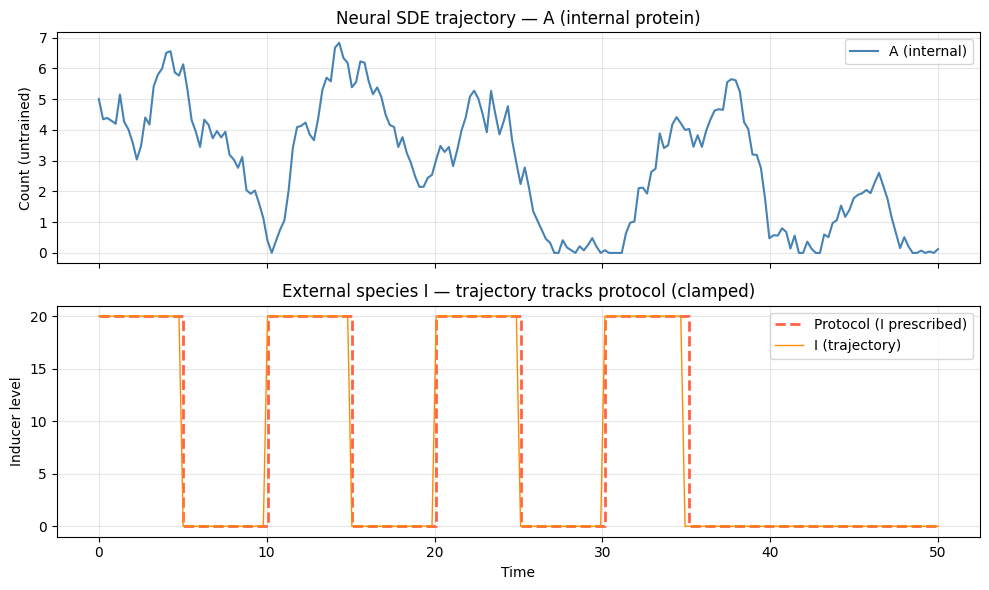


The external species I follows the protocol exactly (clamped by the solver).
Species A shows random dynamics driven by the untrained SDE — values are meaningless.


In [21]:
fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

# Plot internal species A
axes[0].plot(times_np, states_np[:, 0], color="steelblue", linewidth=1.5, label="A (internal)")
axes[0].set_ylabel("Count (untrained)")
axes[0].set_title("Neural SDE trajectory — A (internal protein)")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot external species I alongside the protocol
axes[1].step(
    times_np,
    protocol_values.numpy(),
    where="post",
    color="tomato",
    linewidth=2,
    linestyle="--",
    label="Protocol (I prescribed)",
)
axes[1].plot(times_np, states_np[:, 1], color="darkorange", linewidth=1, label="I (trajectory)")
axes[1].set_xlabel("Time")
axes[1].set_ylabel("Inducer level")
axes[1].set_title("External species I — trajectory tracks protocol (clamped)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nThe external species I follows the protocol exactly (clamped by the solver).")
print("Species A shows random dynamics driven by the untrained SDE — values are meaningless.")

In [22]:
# Also verify the pipeline works with EMPTY_PROTOCOL (no external input)
with torch.no_grad():
    emb_empty_1d = protocol_encoder([EMPTY_PROTOCOL])[0]  # (d_protocol,)
    traj_empty = solver.solve(
        sde=sde,
        initial_state=initial_state.clone(),
        crn_context=crn_context,
        t_span=t_span,
        dt=dt,
        protocol_embedding=emb_empty_1d,
        input_protocol=None,  # no clamping
        external_species_mask=None,
    )

print(f"Trajectory with EMPTY_PROTOCOL shape: {traj_empty.states.shape}  (no crash ✓)")
print(f"Protocol embedding is zero: {emb_empty_1d.abs().max().item():.6f}")

Trajectory with EMPTY_PROTOCOL shape: torch.Size([200, 2])  (no crash ✓)
Protocol embedding is zero: 0.000000


## Summary

| Component | Result |
|---|---|
| `BipartiteGNNEncoder` | Produces identical `CRNContext` on repeated calls (deterministic) |
| `ProtocolEncoder` | Empty protocol → zero embedding; different protocols → different embeddings |
| `CRNNeuralSDE` | drift/diffusion change when protocol embedding changes |
| `EulerMaruyamaSolver` | External species tracks protocol exactly; `EMPTY_PROTOCOL` runs without error |

The full pipeline from CRN structure → protocol → neural trajectory is wired up and functional.  
Training to match SSA trajectories is the next step (see the `GaussianTransitionNLL` loss).